In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

strategy = tf.distribute.MirroredStrategy()
print("Number of devices:", strategy.num_replicas_in_sync)

TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of devices: 2


I0000 00:00:1785405580.429995      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785405580.433245      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [2]:
DATA_DIR = "/kaggle/input/datasets/omkarmanohardalvi/lungs-disease-dataset-4-types/Lung Disease Dataset"

train_dir = os.path.join(DATA_DIR, "train")
val_dir   = os.path.join(DATA_DIR, "val")
test_dir  = os.path.join(DATA_DIR, "test")

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 5

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 6054 images belonging to 5 classes.
Found 2016 images belonging to 5 classes.
Found 2025 images belonging to 5 classes.
Class indices: {'Bacterial Pneumonia': 0, 'Corona Virus Disease': 1, 'Normal': 2, 'Tuberculosis': 3, 'Viral Pneumonia': 4}


In [3]:
with strategy.scope():
    base_model = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dense(512, activation='relu'),
        Dropout(0.4),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,699,013 (29.37 MB)

 Trainable params: 659,461 (2.52 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [4]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-7, verbose=1)
checkpoint = ModelCheckpoint("best_densenet121.keras", monitor='val_accuracy', save_best_only=True, verbose=1)

history = model.fit(
    train_generator,
    epochs=12,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

In [5]:
with strategy.scope():
    base_model.trainable = True
   
    for layer in base_model.layers[:-100]:
        layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

print("Fine-tuning started...")

Fine-tuning started...


In [6]:
history_ft = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/10
INFO:tensorflow:Collective all_reduce tensors: 94 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 725ms/step - accuracy: 0.7832 - loss: 0.5382
Epoch 1: val_accuracy did not improve from 0.83780
190/190 ━━━━━━━━━━━━━━━━━━━━ 204s 897ms/step - accuracy: 0.7818 - loss: 0.5419 - val_accuracy: 0.8289 - val_loss: 0.4354 - learning_rate: 1.0000e-05
Epoch 2/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 734ms/step - accuracy: 0.7773 - loss: 0.5365
Epoch 2: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.

Epoch 2: val_accuracy did not improve from 0.83780
190/190 ━━━━━━━━━━━━━━━━━━━━ 161s 847ms/step - accuracy: 0.7813 - loss: 0.5294 - val_accuracy: 0.8224 - val_loss: 0.4458 - learning_rate: 1.0000e-05
Epoch 3/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 733ms/step - accuracy: 0.8010 - loss: 0.4918
Epoch 3: val_accuracy did not improve from 0.83780
190/190 ━━━━━━━━━━━━━━━━━━━━ 160s 841ms/step -

In [7]:
with strategy.scope():
    base_model.trainable = True
    
    for layer in base_model.layers[:-250]:
        layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=5e-6),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

print("Unfroze last 250 layers")

Unfroze last 250 layers


In [8]:
history_ft2 = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/10
INFO:tensorflow:Collective all_reduce tensors: 94 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 719ms/step - accuracy: 0.7888 - loss: 0.5136
Epoch 1: val_accuracy did not improve from 0.83780
190/190 ━━━━━━━━━━━━━━━━━━━━ 197s 880ms/step - accuracy: 0.7947 - loss: 0.5033 - val_accuracy: 0.8209 - val_loss: 0.4520 - learning_rate: 5.0000e-06
Epoch 2/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 728ms/step - accuracy: 0.7875 - loss: 0.5184
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.4999999621068127e-06.

Epoch 2: val_accuracy did not improve from 0.83780
190/190 ━━━━━━━━━━━━━━━━━━━━ 159s 838ms/step - accuracy: 0.7861 - loss: 0.5135 - val_accuracy: 0.8219 - val_loss: 0.4563 - learning_rate: 5.0000e-06
Epoch 3/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 727ms/step - accuracy: 0.7918 - loss: 0.5135
Epoch 3: val_accuracy did not improve from 0.83780
190/190 ━━━━━━━━━━━━━━━━━━━━ 159s 838ms/step -

In [9]:
model.load_weights("best_densenet121.keras")

test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

64/64 ━━━━━━━━━━━━━━━━━━━━ 40s 631ms/step - accuracy: 0.8435 - loss: 0.3944

Test Accuracy: 84.35%


In [10]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

class_names = list(train_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 433ms/step

Classification Report:
                      precision    recall  f1-score   support

 Bacterial Pneumonia       0.76      0.71      0.74       403
Corona Virus Disease       0.92      0.99      0.95       407
              Normal       0.79      0.99      0.87       404
        Tuberculosis       1.00      0.92      0.96       408
     Viral Pneumonia       0.74      0.61      0.67       403

            accuracy                           0.84      2025
           macro avg       0.84      0.84      0.84      2025
        weighted avg       0.84      0.84      0.84      2025



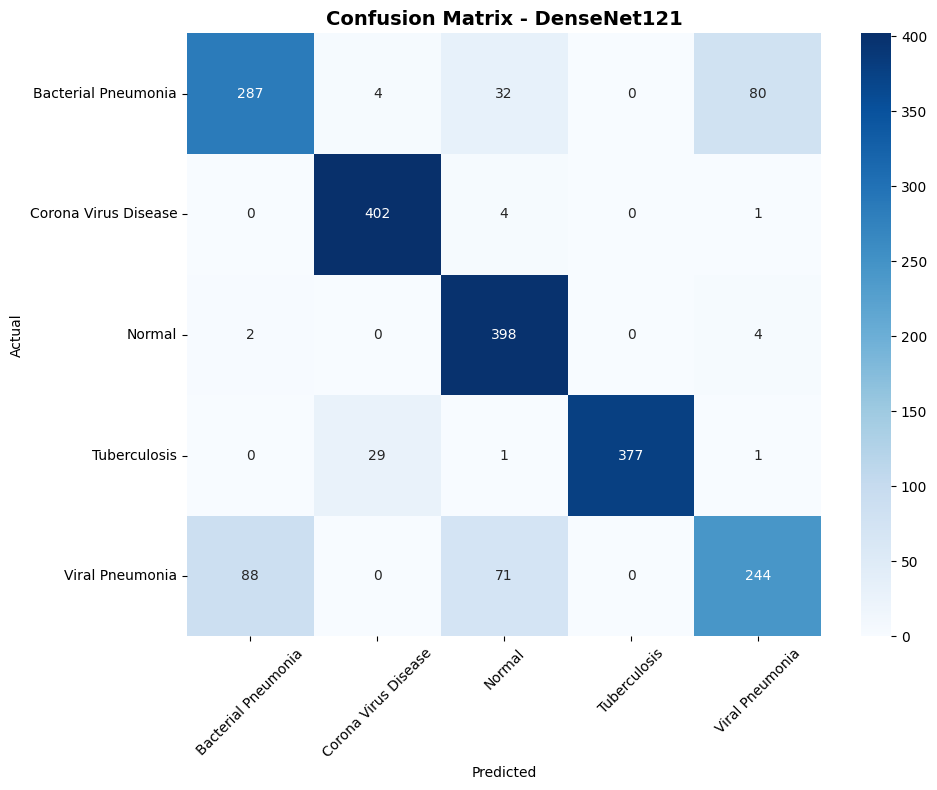

In [11]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - DenseNet121', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
from sklearn.utils.class_weight import compute_class_weight

train_labels = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weight_dict = dict(enumerate(class_weights))
print("Class Weights:")
for i, weight in class_weight_dict.items():
    print(f"{list(train_generator.class_indices.keys())[i]}: {weight:.3f}")

Class Weights:
Bacterial Pneumonia: 1.005
Corona Virus Disease: 0.994
Normal: 1.003
Tuberculosis: 0.992
Viral Pneumonia: 1.006


In [13]:
IMG_SIZE = 299
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.25,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Generators ready → 299×299")

Found 6054 images belonging to 5 classes.
Found 2016 images belonging to 5 classes.
Found 2025 images belonging to 5 classes.
Generators ready → 299×299


In [14]:
with strategy.scope():
    base_model = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dense(512, activation='relu'),
        Dropout(0.4),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 9, 9, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,699,013 (29.37 MB)

 Trainable params: 659,461 (2.52 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [15]:
checkpoint = ModelCheckpoint("best_densenet121_299.keras", monitor='val_accuracy', save_best_only=True, verbose=1)

history_299 = model.fit(
    train_generator,
    epochs=12,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/12
INFO:tensorflow:Collective all_reduce tensors: 8 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.4630 - loss: 1.2766
Epoch 1: val_accuracy improved from None to 0.72917, saving model to best_densenet121_299.keras

Epoch 1: finished saving model to best_densenet121_299.keras
379/379 ━━━━━━━━━━━━━━━━━━━━ 253s 620ms/step - accuracy: 0.5804 - loss: 1.0225 - val_accuracy: 0.7292 - val_loss: 0.6510 - learning_rate: 1.0000e-04
Epoch 2/12
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.6878 - loss: 0.7732
Epoch 2: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.

Epoch 2: val_accuracy improved from 0.72917 to 0.77778, saving model to best_densenet121_299.keras

Epoch 2: finished saving model to best_densenet121_299.keras
379/379 ━━━━━━━━━━━━━━━━━━━━ 229s 604ms/step - accuracy: 0.7032 - loss: 0.7350 - val_accuracy: 0.7778 - val_loss: 0.56

In [16]:
with strategy.scope():
    base_model.trainable = True
    
    for layer in base_model.layers[:-200]:
        layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

print("Fine-tuning 299 model...")

Fine-tuning 299 model...


In [17]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-7, verbose=1)
checkpoint = ModelCheckpoint("best_densenet121_299.keras", monitor='val_accuracy', save_best_only=True, verbose=1)

history_ft_299 = model.fit(
    train_generator,
    epochs=12,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/12
INFO:tensorflow:Collective all_reduce tensors: 179 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.6310 - loss: 0.9072
Epoch 1: val_accuracy improved from None to 0.76885, saving model to best_densenet121_299.keras

Epoch 1: finished saving model to best_densenet121_299.keras
379/379 ━━━━━━━━━━━━━━━━━━━━ 296s 658ms/step - accuracy: 0.6644 - loss: 0.8427 - val_accuracy: 0.7688 - val_loss: 0.5714 - learning_rate: 1.0000e-05
Epoch 2/12
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.7106 - loss: 0.7438
Epoch 2: val_accuracy improved from 0.76885 to 0.78770, saving model to best_densenet121_299.keras

Epoch 2: finished saving model to best_densenet121_299.keras
379/379 ━━━━━━━━━━━━━━━━━━━━ 242s 637ms/step - accuracy: 0.7139 - loss: 0.7233 - val_accuracy: 0.7877 - val_loss: 0.5306 - learning_rate: 1.0000e-05
Epoch 3/12
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 56

In [18]:
model.load_weights("best_densenet121_299.keras")

test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

127/127 ━━━━━━━━━━━━━━━━━━━━ 25s 193ms/step - accuracy: 0.8523 - loss: 0.3966

Test Accuracy: 85.23%


In [19]:
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_names = list(train_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

127/127 ━━━━━━━━━━━━━━━━━━━━ 36s 227ms/step

Classification Report:
                      precision    recall  f1-score   support

 Bacterial Pneumonia       0.76      0.72      0.74       403
Corona Virus Disease       0.95      0.99      0.97       407
              Normal       0.78      0.99      0.87       404
        Tuberculosis       1.00      0.96      0.98       408
     Viral Pneumonia       0.76      0.61      0.68       403

            accuracy                           0.85      2025
           macro avg       0.85      0.85      0.85      2025
        weighted avg       0.85      0.85      0.85      2025



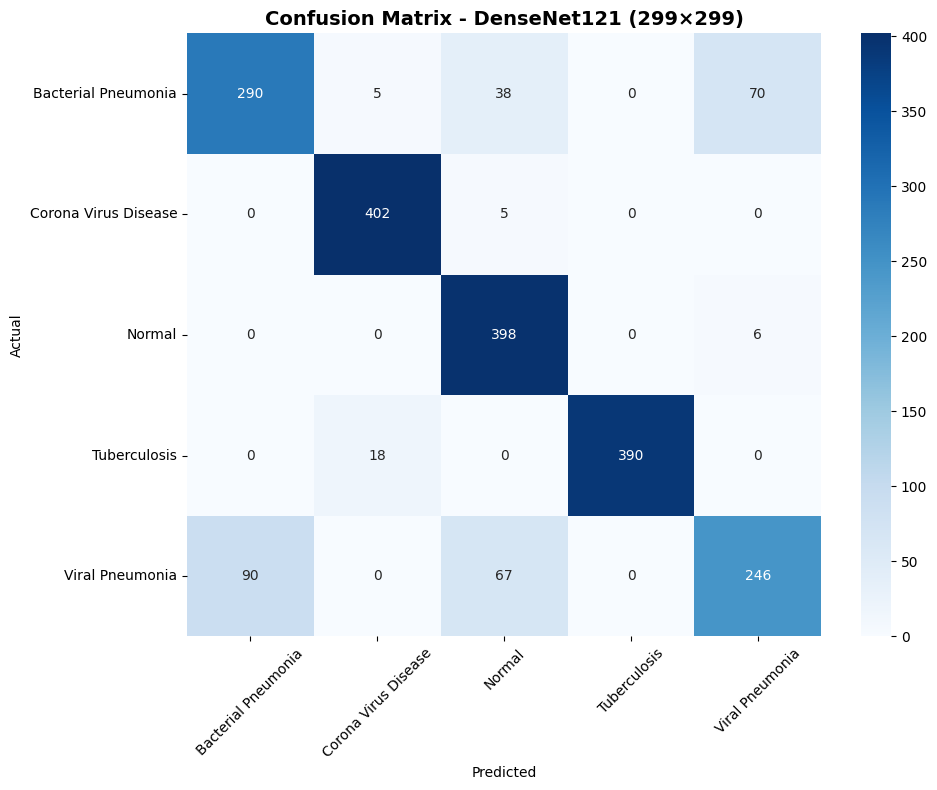

In [20]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - DenseNet121 (299×299)', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
with strategy.scope():
    base_model.trainable = True
    
    for layer in base_model.layers[:50]:
        layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=3e-6),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

print("Final strong fine-tuning ready")

Final strong fine-tuning ready


In [22]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-8, verbose=1)
checkpoint = ModelCheckpoint("best_densenet121_final.keras", monitor='val_accuracy', save_best_only=True, verbose=1)

history_final = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/15
INFO:tensorflow:Collective all_reduce tensors: 179 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.8161 - loss: 0.4574
Epoch 1: val_accuracy improved from None to 0.84623, saving model to best_densenet121_final.keras

Epoch 1: finished saving model to best_densenet121_final.keras
379/379 ━━━━━━━━━━━━━━━━━━━━ 295s 657ms/step - accuracy: 0.8224 - loss: 0.4467 - val_accuracy: 0.8462 - val_loss: 0.3939 - learning_rate: 3.0000e-06
Epoch 2/15
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.8240 - loss: 0.4507
Epoch 2: val_accuracy did not improve from 0.84623
379/379 ━━━━━━━━━━━━━━━━━━━━ 236s 621ms/step - accuracy: 0.8231 - loss: 0.4500 - val_accuracy: 0.8433 - val_loss: 0.3943 - learning_rate: 3.0000e-06
Epoch 3/15
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.8121 - loss: 0.4669
Epoch 3: ReduceLROnPlateau reducing learning rate to 9.00000031

In [23]:
model.load_weights("best_densenet121_final.keras")

test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

127/127 ━━━━━━━━━━━━━━━━━━━━ 25s 197ms/step - accuracy: 0.8578 - loss: 0.3786

Final Test Accuracy: 85.78%


In [24]:
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_names = list(train_generator.class_indices.keys())

print("\nFinal Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

127/127 ━━━━━━━━━━━━━━━━━━━━ 42s 258ms/step

Final Classification Report:
                      precision    recall  f1-score   support

 Bacterial Pneumonia       0.77      0.72      0.74       403
Corona Virus Disease       0.94      0.99      0.97       407
              Normal       0.81      0.99      0.89       404
        Tuberculosis       1.00      0.96      0.98       408
     Viral Pneumonia       0.76      0.64      0.69       403

            accuracy                           0.86      2025
           macro avg       0.86      0.86      0.85      2025
        weighted avg       0.86      0.86      0.85      2025

